# 微调Mask2Former

In [1]:
# 安装额外依赖（如已安装可跳过）
!pip install segmentation_models_pytorch albumentations torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.5 MB/s eta 0:00:00


In [2]:
import os
import time
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import cv2
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import albumentations as A
from albumentations.pytorch import ToTensorV2

import transformers
from transformers import (
    AutoImageProcessor,
    Mask2FormerImageProcessor,
    Mask2FormerForUniversalSegmentation,
)

In [3]:
print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Transformers: 5.0.0
PyTorch: 2.10.0+cu128
CUDA: 12.8
GPU: Tesla T4


## 全局设置

In [4]:
IMAGE_DIR = "/kaggle/input/datasets/xiaose/cityscapes/Cityspaces/images"
MASK_DIR = "/kaggle/input/datasets/xiaose/cityscapes/Cityspaces/gtFine"
TRAIN_IMAGE_DIR = os.path.join(IMAGE_DIR, "train")
TRAIN_MASK_DIR = os.path.join(MASK_DIR, "train")
VAL_IMAGE_DIR = os.path.join(IMAGE_DIR, "val")
VAL_MASK_DIR = os.path.join(MASK_DIR, "val")

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [6]:
# Model
CHECKPOINT = (
    "facebook/mask2former-swin-small-cityscapes-panoptic"
)

In [7]:
# Dataset
CITYSCAPES_CLASSES = [
    "road",
    "sidewalk",
    "building",
    "wall",
    "fence",
    "pole",
    "traffic_light",
    "traffic_sign",
    "vegetation",
    "terrain",
    "sky",
    "person",
    "rider",
    "car",
    "truck",
    "bus",
    "train",
    "motorcycle",
    "bicycle",
]

id2label = {
    i: name
    for i, name in enumerate(CITYSCAPES_CLASSES)
}
label2id = {
    name: i
    for i, name in enumerate(CITYSCAPES_CLASSES)
}

NUM_CLASSES = len(CITYSCAPES_CLASSES)
IGNORE_INDEX = 255

In [8]:
# Training
BATCH_SIZE = 2
NUM_WORKERS = 4
EPOCHS = 4
# Optimizer
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.05
# Gradient
MAX_GRAD_NORM = 1.0
# AMP
USE_AMP = True
# Logging
LOG_INTERVAL = 20
# Scheduler
ETA_MIN = 1e-6

In [9]:
# Checkpoint
OUTPUT_DIR = "/kaggle/working/"
BEST_MODEL_DIR = os.path.join(OUTPUT_DIR,"best_model")
os.makedirs(
    BEST_MODEL_DIR,
    exist_ok=True
)

SAVE_EVERY = 1

## 加载数据

In [10]:
# Cityscapes Dataset
class CityscapesDataset(Dataset):

    def __init__(self, image_dir, mask_dir, transforms=None):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transforms = transforms
        self.image_list = []

        for city in sorted(os.listdir(self.image_dir)):
            city_dir = os.path.join(self.image_dir, city)
            
            if not os.path.isdir(city_dir):
                continue

            for filename in sorted(os.listdir(city_dir)):
                if filename.endswith("_leftImg8bit.png"):

                    self.image_list.append(
                        (city, filename)
                    )

        print(f"Found {len(self.image_list)} images")

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):

        city, image_name = self.image_list[idx]
        
        # Image
        image_path = os.path.join(self.image_dir, city, image_name)
        # Mask
        mask_name = image_name.replace(
            "_leftImg8bit.png",
            "_gtFine_labelTrainIds.png",
        )
        mask_path = os.path.join(self.mask_dir, city, mask_name)
        # Read image
        image = np.array(Image.open(image_path).convert("RGB"))
        
        # Read Cityscapes trainIds
        # 0 ~ 18 : valid classes
        # 255    : ignore
        mask = np.array(Image.open(mask_path), dtype=np.uint8)
        
        # Albumentations
        if self.transforms is not None:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        return {
            "image": image,
            "mask": mask,
            "image_path": image_path,
        }


# Albumentations
def get_transforms(mode="train", height=512, width=512):

    if mode == "train":
        return A.Compose([
            A.Resize(
                height=height,
                width=width,
                interpolation=cv2.INTER_LINEAR,
            ),

            A.HorizontalFlip(
                p=0.5
            ),

            A.OneOf([
                A.RandomBrightnessContrast(
                    brightness_limit=0.2,
                    contrast_limit=0.2,
                    p=1.0,
                ),

                A.HueSaturationValue(
                    hue_shift_limit=10,
                    sat_shift_limit=15,
                    val_shift_limit=10,
                    p=1.0,
                ),
            ], p=0.5),
        ])

    elif mode == "val":

        return A.Compose([
            A.Resize(
                height=height,
                width=width,
                interpolation=cv2.INTER_LINEAR,
            ),
        ])

    else:

        raise ValueError("mode must be 'train' or 'val'")

In [11]:
train_base = CityscapesDataset(
    image_dir=TRAIN_IMAGE_DIR,
    mask_dir=TRAIN_MASK_DIR,
    transforms=get_transforms(
        mode="train",
        height=512,
        width=512,
    ),
)

val_base = CityscapesDataset(
    image_dir=VAL_IMAGE_DIR,
    mask_dir=VAL_MASK_DIR,
    transforms=get_transforms(
        mode="val",
        height=512,
        width=512,
    ),
)

Found 2975 images
Found 500 images


## 构建DataLoader

### Mask2Former Processor

In [12]:
# Mask2Former Processor
processor = Mask2FormerImageProcessor(
    do_resize=False,
    do_rescale=True,
    do_normalize=True,
    ignore_index=IGNORE_INDEX,
    do_reduce_labels=False,
)

# Mask2Former Dataset
class Mask2FormerDataset(Dataset):
    def __init__(self, cityscapes_dataset, processor,):

        self.dataset = cityscapes_dataset
        self.processor = processor

    def __len__(self):

        return len(self.dataset)

    def __getitem__(self, idx):

        sample = self.dataset[idx]
        image = sample["image"]
        mask = sample["mask"]

        # Keep original semantic GT
        semantic_mask = torch.from_numpy(mask.copy()).long()
        # Mask2Former processor
        encoded = self.processor(images=image, segmentation_maps=mask, return_tensors="pt")
        
        pixel_values = (
            encoded["pixel_values"]
            .squeeze(0)
        )

        if "pixel_mask" in encoded:
            pixel_mask = (
                encoded["pixel_mask"]
                .squeeze(0)
            )
        else:
            pixel_mask = None

        mask_labels = encoded["mask_labels"][0]
        class_labels = encoded["class_labels"][0]

        return {
            "pixel_values": pixel_values,
            "pixel_mask": pixel_mask,
            "mask_labels": mask_labels,
            "class_labels": class_labels,
            # Original semantic GT
            "semantic_mask": semantic_mask,
            "image_path": sample["image_path"],
        }

In [13]:
train_dataset = Mask2FormerDataset(
    cityscapes_dataset=train_base,
    processor=processor,
)

val_dataset = Mask2FormerDataset(
    cityscapes_dataset=val_base,
    processor=processor,
)

In [14]:
sample = train_dataset[0]

print("keys:", sample.keys())
print(
    "pixel_values:",
    sample["pixel_values"].shape,
    sample["pixel_values"].dtype
)
print(
    "pixel_mask:",
    None if sample["pixel_mask"] is None
    else sample["pixel_mask"].shape
)
print(
    "mask_labels:",
    sample["mask_labels"].shape,
    sample["mask_labels"].dtype
)
print(
    "class_labels:",
    sample["class_labels"].shape,
    sample["class_labels"].dtype
)
print(
    "classes:",
    sample["class_labels"].tolist()
)

keys: dict_keys(['pixel_values', 'pixel_mask', 'mask_labels', 'class_labels', 'semantic_mask', 'image_path'])
pixel_values: torch.Size([3, 512, 512]) torch.float32
pixel_mask: torch.Size([512, 512])
mask_labels: torch.Size([12, 512, 512]) torch.float32
class_labels: torch.Size([12]) torch.int64
classes: [0, 1, 2, 5, 7, 8, 9, 10, 11, 12, 13, 18]


### DataLoader

In [15]:
# Collate Function
def collate_fn(batch):

    pixel_values = torch.stack([
        item["pixel_values"]
        for item in batch
    ])

    pixel_masks = [
        item["pixel_mask"]
        for item in batch
    ]

    mask_labels = [
        item["mask_labels"]
        for item in batch
    ]

    class_labels = [
        item["class_labels"]
        for item in batch
    ]

    semantic_masks = torch.stack([
        item["semantic_mask"]
        for item in batch
    ])

    image_paths = [
        item["image_path"]
        for item in batch
    ]

    if all(
        x is not None
        for x in pixel_masks
    ):
        pixel_mask = torch.stack(pixel_masks)

    else:
        pixel_mask = None

    return {
        "pixel_values": pixel_values,
        "pixel_mask": pixel_mask,
        "mask_labels": mask_labels,
        "class_labels": class_labels,
        "semantic_mask": semantic_masks,
        "image_paths": image_paths,
    }

In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_fn,
)

In [17]:
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

Train samples: 2975
Val samples: 500


In [18]:
batch = next(iter(train_loader))

print("pixel_values:", batch["pixel_values"].shape)
print("batch size:", len(batch["mask_labels"]))

for i in range(len(batch["mask_labels"])):
    print(
        f"Image {i}:",
        "mask_labels =",
        batch["mask_labels"][i].shape,
        "class_labels =",
        batch["class_labels"][i].shape,
        "classes =",
        batch["class_labels"][i].tolist(),
    )

pixel_values: torch.Size([2, 3, 512, 512])
batch size: 2
Image 0: mask_labels = torch.Size([9, 512, 512]) class_labels = torch.Size([9]) classes = [0, 1, 2, 4, 5, 7, 8, 11, 18]
Image 1: mask_labels = torch.Size([12, 512, 512]) class_labels = torch.Size([12]) classes = [0, 1, 2, 4, 5, 7, 8, 9, 10, 11, 13, 18]


## 加载Mask2Former

In [19]:
processor = Mask2FormerImageProcessor.from_pretrained(
    CHECKPOINT,
)

preprocessor_config.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `Mask2FormerImageProcessor.__init__` and were ignored: '_max_size', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


In [20]:
# 查看 processor 的所有属性
print("All attributes:")
for attr in dir(processor):
    if not attr.startswith('_'):
        print(f"  {attr}")

All attributes:
  center_crop
  convert_segmentation_map_to_binary_masks
  do_normalize
  do_reduce_labels
  do_rescale
  do_resize
  encode_inputs
  fetch_images
  from_dict
  from_json_file
  from_pretrained
  get_image_processor_dict
  ignore_index
  image_mean
  image_processor_type
  image_std
  is_fast
  model_input_names
  normalize
  num_labels
  pad
  pad_size
  post_process_instance_segmentation
  post_process_panoptic_segmentation
  post_process_semantic_segmentation
  preprocess
  push_to_hub
  register_for_auto_class
  resample
  rescale
  rescale_factor
  resize
  save_pretrained
  size
  size_divisor
  to_dict
  to_json_file
  to_json_string
  valid_kwargs


In [21]:
processor = Mask2FormerImageProcessor.from_pretrained(
    CHECKPOINT,
    do_reduce_labels=False,
)

print(processor)

Mask2FormerImageProcessor {
  "do_normalize": true,
  "do_reduce_labels": false,
  "do_rescale": true,
  "do_resize": true,
  "ignore_index": 255,
  "image_mean": [
    0.48500001430511475,
    0.4560000002384186,
    0.4059999883174896
  ],
  "image_processor_type": "Mask2FormerImageProcessor",
  "image_std": [
    0.2290000021457672,
    0.2239999920129776,
    0.22499999403953552
  ],
  "num_labels": 19,
  "pad_size": null,
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 384,
    "width": 384
  },
  "size_divisor": 32
}



In [22]:
model = Mask2FormerForUniversalSegmentation.from_pretrained(
    CHECKPOINT,

    # Cityscapes semantic segmentation = 19 classes
    num_labels=NUM_CLASSES,

    # Label mapping
    id2label=id2label,
    label2id=label2id,

    # Because checkpoint's classification head
    # may not have exactly 19 classes
    ignore_mismatched_sizes=True,
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/276M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/275M [00:00<?, ?B/s]

In [23]:
print(model.config.num_labels)
print(model.config.id2label)

19
{0: 'road', 1: 'sidewalk', 2: 'building', 3: 'wall', 4: 'fence', 5: 'pole', 6: 'traffic_light', 7: 'traffic_sign', 8: 'vegetation', 9: 'terrain', 10: 'sky', 11: 'person', 12: 'rider', 13: 'car', 14: 'truck', 15: 'bus', 16: 'train', 17: 'motorcycle', 18: 'bicycle'}


### 单批次Forward

In [24]:
batch = next(iter(train_loader))

print("pixel_values:")
print(batch["pixel_values"].shape)

print("pixel_mask:")
print(batch["pixel_mask"].shape)

print("mask_labels:")
for x in batch["mask_labels"]:
    print(x.shape)

print("class_labels:")
for x in batch["class_labels"]:
    print(x.shape)

pixel_values:
torch.Size([2, 3, 512, 512])
pixel_mask:
torch.Size([2, 512, 512])
mask_labels:
torch.Size([14, 512, 512])
torch.Size([12, 512, 512])
class_labels:
torch.Size([14])
torch.Size([12])


In [25]:
model = model.to(DEVICE)
model.train()

Mask2FormerForUniversalSegmentation(
  (model): Mask2FormerModel(
    (pixel_level_module): Mask2FormerPixelLevelModule(
      (encoder): SwinBackbone(
        (embeddings): SwinEmbeddings(
          (patch_embeddings): SwinPatchEmbeddings(
            (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
          )
          (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (encoder): SwinEncoder(
          (layers): ModuleList(
            (0): SwinStage(
              (blocks): ModuleList(
                (0): SwinLayer(
                  (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
                  (attention): SwinAttention(
                    (self): SwinSelfAttention(
                      (query): Linear(in_features=96, out_features=96, bias=True)
                      (key): Linear(in_features=96, out_features=96, bias=True)
                      (value): Lin

In [26]:
pixel_values = batch["pixel_values"].to(
    DEVICE,
    non_blocking=True,
)

pixel_mask = batch["pixel_mask"].to(
    DEVICE,
    non_blocking=True,
)

mask_labels = [
    x.to(
        DEVICE,
        non_blocking=True,
    )
    for x in batch["mask_labels"]
]

class_labels = [
    x.to(
        DEVICE,
        non_blocking=True,
    )
    for x in batch["class_labels"]
]

In [27]:
outputs = model(
    pixel_values=pixel_values,
    pixel_mask=pixel_mask,
    mask_labels=mask_labels,
    class_labels=class_labels,
)

In [28]:
print("Loss:",outputs.loss)
print("Loss value:",outputs.loss.item())

Loss: tensor(33.8913, device='cuda:0', grad_fn=<AddBackward0>)
Loss value: 33.89125442504883


In [29]:
print("class_queries_logits:",outputs.class_queries_logits.shape)
print("masks_queries_logits:",outputs.masks_queries_logits.shape)

class_queries_logits: torch.Size([2, 100, 20])
masks_queries_logits: torch.Size([2, 100, 128, 128])


```python
class_queries_logits
    [B, num_queries, num_classes + 1]

masks_queries_logits
    [B, num_queries, H, W]
```
- 注意第二个空间尺寸不一定是 512×512
- Mask2Former 在内部使用 backbone / pixel decoder 的 feature resolution 进行 mask prediction，最终通过 processor 的 post-processing 恢复到目标尺寸。

In [30]:
outputs.loss.backward()

In [31]:
for name, param in model.named_parameters():

    if param.grad is not None:

        print("First parameter with gradient:", name)
        print("Gradient norm:", param.grad.norm().item())

        break

First parameter with gradient: model.pixel_level_module.encoder.embeddings.patch_embeddings.projection.weight
Gradient norm: 145.49078369140625


## 精度计算

In [32]:
def compute_miou(predictions, targets, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX,):
    """
    Compute semantic segmentation mIoU.

    Parameters
    ----------
    predictions : torch.Tensor
        [N, H, W]

    targets : torch.Tensor
        [N, H, W]

    Returns
    -------
    miou : float
    class_iou : np.ndarray
    """
    
    predictions = predictions.detach().cpu()
    targets = targets.detach().cpu()

    # Ignore 255
    valid = (
        targets != ignore_index
    )
    predictions = predictions[valid]
    targets = targets[valid]

    # Confusion matrix
    confusion_matrix = torch.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=torch.int64,
    )
    indices = (
        targets * num_classes
        + predictions
    )
    bincount = torch.bincount(
        indices,
        minlength=num_classes * num_classes,
    )
    confusion_matrix = bincount.reshape(
        num_classes,
        num_classes,
    )

    # IoU
    tp = torch.diag(confusion_matrix)
    fp = (confusion_matrix.sum(dim=0) - tp)
    fn = (confusion_matrix.sum(dim=1) - tp)
    denominator = (tp + fp + fn)
    class_iou = torch.where(
        denominator > 0,
        tp.float() / denominator.float(),
        torch.tensor(
            float("nan")
        ),
    )
    miou = torch.nanmean(class_iou)

    return (
        miou.item(),
        class_iou.numpy(),
    )

In [33]:
def print_class_iou(class_iou,):
    print("\n" + "=" * 60)
    print("Cityscapes Class IoU")
    print("=" * 60)

    for class_name, iou in zip(CITYSCAPES_CLASSES, class_iou):
        if np.isnan(iou):
            value = "NaN"
        else:
            value = f"{iou * 100:.2f}%"

        print(
            f"{class_name:<16} "
            f"{value}"
        )
        
    print("=" * 60)

## 训练函数

In [34]:
def move_batch_to_device(batch, device=DEVICE):

    pixel_values = batch[
        "pixel_values"
    ].to(
        device,
        non_blocking=True,
    )

    pixel_mask = batch.get("pixel_mask", None)
    if pixel_mask is not None:
        pixel_mask = pixel_mask.to(device, non_blocking=True)

    mask_labels = [
        x.to(
            device,
            non_blocking=True,
        )
        for x in batch["mask_labels"]
    ]

    class_labels = [
        x.to(
            device,
            non_blocking=True,
        )
        for x in batch["class_labels"]
    ]

    return (
        pixel_values,
        pixel_mask,
        mask_labels,
        class_labels,
    )

In [35]:
def train_one_epoch(model, train_loader, optimizer, scaler, epoch,):
    """
    Train Mask2Former for one epoch.

    Returns
    -------
    epoch_loss : float
    """

    model.train()
    running_loss = 0.0
    num_batches = len(train_loader)
    start_time = time.time()
    progress_bar = tqdm(
        enumerate(train_loader),
        total=num_batches,
        desc=f"Train [{epoch}/{EPOCHS}]",
        leave=True,
    )

    for step, batch in progress_bar:
        # Move batch to GPU
        (
            pixel_values,
            pixel_mask,
            mask_labels,
            class_labels,
        ) = move_batch_to_device(batch)

        # Clear gradients
        optimizer.zero_grad(set_to_none=True)

        # Forward
        if scaler is not None:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(
                    pixel_values=pixel_values,
                    pixel_mask=pixel_mask,
                    mask_labels=mask_labels,
                    class_labels=class_labels,
                )
                loss = outputs.loss
        else:
            outputs = model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask,
                mask_labels=mask_labels,
                class_labels=class_labels,
            )
            loss = outputs.loss

        # Check NaN / Inf
        if not torch.isfinite(loss):
            print(
                f"\nWARNING: Non-finite loss "
                f"at epoch={epoch}, step={step}"
            )
            print("Loss:", loss.item())
            
            optimizer.zero_grad(set_to_none=True)

            continue

        # Backward
        if scaler is not None:
            scaler.scale(loss).backward()
            # Unscale before clipping
            scaler.unscale_(optimizer)
            grad_norm = (
                torch.nn.utils
                .clip_grad_norm_(
                    model.parameters(),
                    MAX_GRAD_NORM,
                )
            )
            scaler.step(optimizer)
            scaler.update()

        else:
            loss.backward()
            grad_norm = (
                torch.nn.utils
                .clip_grad_norm_(
                    model.parameters(),
                    MAX_GRAD_NORM,
                )
            )
            optimizer.step()

        # Loss
        loss_value = loss.detach().item()
        running_loss += loss_value
        avg_loss = running_loss / (step + 1)

        # LR
        current_lr = optimizer.param_groups[0]["lr"]

        # Progress bar
        progress_bar.set_postfix(
            loss=f"{loss_value:.4f}",
            avg=f"{avg_loss:.4f}",
            lr=f"{current_lr:.2e}",
            grad=f"{float(grad_norm):.2f}",
        )

        # Logging
        if (
            LOG_INTERVAL > 0
            and (step + 1) % LOG_INTERVAL == 0
        ):
            elapsed = time.time() - start_time

            print(
                f"\n"
                f"Epoch [{epoch}/{EPOCHS}] "
                f"Step [{step + 1}/{num_batches}] "
                f"Loss: {loss_value:.4f} "
                f"Avg: {avg_loss:.4f} "
                f"LR: {current_lr:.2e} "
                f"Grad: {float(grad_norm):.2f} "
                f"Time: {elapsed / 60:.2f} min"
            )

    # Epoch loss
    epoch_loss = running_loss / num_batches
    epoch_time = time.time() - start_time

    return epoch_loss, epoch_time

## 验证函数

In [36]:
@torch.no_grad()
def validate(model, val_loader, processor,):
    """
    Validate Mask2Former.

    Returns
    -------
    val_loss : float
    miou : float
    class_iou : np.ndarray
    """

    model.eval()
    running_loss = 0.0
    num_batches = len(val_loader)

    # Global confusion matrix
    confusion_matrix = torch.zeros(
        (
            NUM_CLASSES,
            NUM_CLASSES,
        ),
        dtype=torch.int64,
    )

    start_time = time.time()

    progress_bar = tqdm(
        val_loader,
        total=num_batches,
        desc="Validation",
        leave=True,
    )

    for batch in progress_bar:

        # Move inputs
        (
            pixel_values,
            pixel_mask,
            mask_labels,
            class_labels,
        ) = move_batch_to_device(batch)

        # Forward
        if USE_AMP and DEVICE.type == "cuda":

            with torch.autocast(device_type="cuda", dtype=torch.float16,):
                outputs = model(
                    pixel_values=pixel_values,
                    pixel_mask=pixel_mask,
                    mask_labels=mask_labels,
                    class_labels=class_labels,
                )
        else:
            outputs = model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask,
                mask_labels=mask_labels,
                class_labels=class_labels,
            )
            
        # Loss
        if outputs.loss is not None:
            running_loss += outputs.loss.item()

        # Prediction target sizes
        target_sizes = [
            (
                batch["semantic_mask"][i].shape[-2],
                batch["semantic_mask"][i].shape[-1],
            )
            for i in range(
                len(batch["semantic_mask"])
            )
        ]

        # Mask2Former → semantic segmentation
        predictions = (
            processor
            .post_process_semantic_segmentation(
                outputs,
                target_sizes=target_sizes,
            )
        )

        # Update confusion matrix
        for pred, target in zip(predictions, batch["semantic_mask"]):
            pred = pred.cpu()
            target = target.cpu()

            # Ignore label = 255
            valid = (
                target != IGNORE_INDEX
            )
            pred = pred[valid]
            target = target[valid]
            
            # Safety
            valid = (
                (target >= 0)
                & (target < NUM_CLASSES)
                & (pred >= 0)
                & (pred < NUM_CLASSES)
            )
            pred = pred[valid]
            target = target[valid]

            # Confusion matrix
            indices = target * NUM_CLASSES + pred
            bincount = torch.bincount(
                indices,
                minlength=(
                    NUM_CLASSES
                    * NUM_CLASSES
                ),
            )
            confusion_matrix += (
                bincount.reshape(
                    NUM_CLASSES,
                    NUM_CLASSES,
                )
            )

        # Progress
        current_loss = running_loss / max(1, len(progress_bar))
        progress_bar.set_postfix(loss=f"{current_loss:.4f}")

    # IoU
    tp = torch.diag(confusion_matrix)
    fp = confusion_matrix.sum(dim=0) - tp
    fn = confusion_matrix.sum(dim=1) - tp
    denominator = tp + fp + fn
    class_iou = torch.where(
        denominator > 0,
        tp.float()
        / denominator.float(),
        torch.tensor(
            float("nan")
        ),
    )
    miou = torch.nanmean(class_iou).item()
    val_loss = running_loss / num_batches
    epoch_time = time.time() - start_time

    return (
        val_loss,
        miou,
        class_iou.numpy(),
        epoch_time,
    )

In [37]:
def save_best_model(model, processor, miou, epoch, best_miou,):

    os.makedirs(BEST_MODEL_DIR, exist_ok=True)

    # Hugging Face model
    model.save_pretrained(BEST_MODEL_DIR)
    processor.save_pretrained(BEST_MODEL_DIR)

    # Training metadata
    metadata = {
        "epoch": epoch,
        "miou": float(miou),
        "best_miou": float(best_miou),
        "num_classes": NUM_CLASSES,
        "classes": CITYSCAPES_CLASSES,
        "checkpoint": CHECKPOINT,
    }

    with open(
        os.path.join(
            BEST_MODEL_DIR,
            "training_info.json",
        ),
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            metadata,
            f,
            indent=4,
            ensure_ascii=False,
        )

    print(
        f"\nBest model saved:"
        f"\n{BEST_MODEL_DIR}"
    )

## Training

In [38]:
model = model.to(DEVICE)

In [39]:
# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Scheduler
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=ETA_MIN,
)

# AMP Scaler
if (USE_AMP and DEVICE.type == "cuda"):
    scaler = torch.amp.GradScaler("cuda")
    print(scaler)
else:
    scaler = None
    print(scaler)

In [40]:
best_miou = -1.0

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "miou": [],
    "learning_rate": [],
    "epoch_time": [],
}

In [41]:
for epoch in range(1, EPOCHS + 1,):

    print("=" * 80)
    print(f"Epoch {epoch}/{EPOCHS}")
    print("=" * 80)

    # Train
    train_loss, train_time = (
        train_one_epoch(
            model=model,
            train_loader=train_loader,
            optimizer=optimizer,
            scaler=scaler,
            epoch=epoch,
        )
    )
    
    # Validation
    (
        val_loss,
        miou,
        class_iou,
        val_time,
    ) = validate(
        model=model,
        val_loader=val_loader,
        processor=processor,
    )


    # Scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    # History
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["miou"].append(miou)
    history["learning_rate"].append(current_lr)
    history["epoch_time"].append(train_time + val_time)

    # Print
    print("\n")
    print("=" * 80)

    print(f"Epoch [{epoch}/{EPOCHS}]")
    print(f"Train Loss : {train_loss:.6f}")
    print(f"Val Loss   : {val_loss:.6f}")
    print(f"Val mIoU   : {miou * 100:.4f}%")
    print(f"Learning Rate : {current_lr:.6e}")
    print(
        f"Time : "
        f"{(train_time + val_time) / 60:.2f} min"
    )
    print("=" * 80)

    # Class IoU
    print_class_iou(class_iou)

    # Best model
    if miou > best_miou:
        best_miou = miou
        save_best_model(
            model=model,
            processor=processor,
            miou=miou,
            epoch=epoch,
            best_miou=best_miou,
        )
        print(
            f"\nNew BEST mIoU: "
            f"{best_miou * 100:.4f}%"
        )
    else:
        print(
            f"\nBest mIoU remains: "
            f"{best_miou * 100:.4f}%"
        )

    # Save training history
    # This is NOT a model checkpoint.
    with open(
        os.path.join(
            OUTPUT_DIR,
            "history.json",
        ),
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            history,
            f,
            indent=4,
        )



Epoch 1/4


Train [1/4]:   0%|          | 0/1487 [00:00<?, ?it/s]


Epoch [1/4] Step [20/1487] Loss: 38.1012 Avg: 36.0728 LR: 1.00e-04 Grad: 195.55 Time: 0.19 min

Epoch [1/4] Step [40/1487] Loss: 19.3739 Avg: 32.5141 LR: 1.00e-04 Grad: 153.59 Time: 0.35 min

Epoch [1/4] Step [60/1487] Loss: 25.9648 Avg: 30.8370 LR: 1.00e-04 Grad: 163.81 Time: 0.51 min

Epoch [1/4] Step [80/1487] Loss: 33.9555 Avg: 29.9450 LR: 1.00e-04 Grad: 202.80 Time: 0.68 min

Epoch [1/4] Step [100/1487] Loss: 34.0726 Avg: 29.1394 LR: 1.00e-04 Grad: 266.24 Time: 0.85 min

Epoch [1/4] Step [120/1487] Loss: 26.4990 Avg: 28.5901 LR: 1.00e-04 Grad: 137.98 Time: 1.02 min

Epoch [1/4] Step [140/1487] Loss: 25.7572 Avg: 28.2028 LR: 1.00e-04 Grad: 111.52 Time: 1.19 min

Epoch [1/4] Step [160/1487] Loss: 27.8776 Avg: 27.7655 LR: 1.00e-04 Grad: 207.79 Time: 1.35 min

Epoch [1/4] Step [180/1487] Loss: 21.1470 Avg: 27.5341 LR: 1.00e-04 Grad: 135.12 Time: 1.52 min

Epoch [1/4] Step [200/1487] Loss: 27.8767 Avg: 27.4967 LR: 1.00e-04 Grad: 1364.35 Time: 1.69 min

Epoch [1/4] Step [220/1487] Loss

Validation:   0%|          | 0/250 [00:00<?, ?it/s]



Epoch [1/4]
Train Loss : 25.517249
Val Loss   : 24.941149
Val mIoU   : 66.3826%
Learning Rate : 8.550179e-05
Time : 13.41 min

Cityscapes Class IoU
road             97.73%
sidewalk         81.97%
building         89.24%
wall             53.23%
fence            44.89%
pole             42.09%
traffic_light    53.94%
traffic_sign     66.07%
vegetation       89.85%
terrain          60.58%
sky              92.91%
person           65.94%
rider            40.07%
car              92.07%
truck            52.43%
bus              75.62%
train            54.22%
motorcycle       44.21%
bicycle          64.21%


...


Epoch [4/4] Step [20/1487] Loss: 17.1274 Avg: 18.7270 LR: 1.55e-05 Grad: 115.63 Time: 0.54 min

Epoch [4/4] Step [40/1487] Loss: 19.3034 Avg: 18.6954 LR: 1.55e-05 Grad: 81.20 Time: 0.72 min

Epoch [4/4] Step [60/1487] Loss: 18.3648 Avg: 17.8108 LR: 1.55e-05 Grad: 83.25 Time: 0.90 min

Epoch [4/4] Step [80/1487] Loss: 8.9700 Avg: 17.6486 LR: 1.55e-05 Grad: 41.97 Time: 1.08 min

Epoch [4/4] Step [100/1487] Loss: 14.5275 Avg: 17.5622 LR: 1.55e-05 Grad: 62.21 Time: 1.26 min

Epoch [4/4] Step [120/1487] Loss: 17.0520 Avg: 17.5873 LR: 1.55e-05 Grad: 72.54 Time: 1.44 min

Epoch [4/4] Step [140/1487] Loss: 14.4753 Avg: 17.5387 LR: 1.55e-05 Grad: 106.89 Time: 1.61 min

Epoch [4/4] Step [160/1487] Loss: 19.2862 Avg: 17.5039 LR: 1.55e-05 Grad: 56.93 Time: 1.79 min

Epoch [4/4] Step [180/1487] Loss: 16.0202 Avg: 17.6068 LR: 1.55e-05 Grad: 97.63 Time: 1.96 min

Epoch [4/4] Step [200/1487] Loss: 21.2717 Avg: 17.6391 LR: 1.55e-05 Grad: 162.02 Time: 2.14 min

Epoch [4/4] Step [220/1487] Loss: 12.7720

Validation:   0%|          | 0/250 [00:00<?, ?it/s]



Epoch [4/4]
Train Loss : 17.320362
Val Loss   : 22.263617
Val mIoU   : 72.8621%
Learning Rate : 1.000000e-06
Time : 14.12 min

Cityscapes Class IoU
road             98.14%
sidewalk         84.34%
building         90.86%
wall             60.24%
fence            52.07%
pole             47.15%
traffic_light    58.80%
traffic_sign     70.06%
vegetation       90.70%
terrain          64.77%
sky              93.33%
person           73.33%
rider            52.35%
car              93.15%
truck            69.18%
bus              87.00%
train            77.10%
motorcycle       51.84%
bicycle          69.97%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Best model saved:
/kaggle/working/best_model

New BEST mIoU: 72.8621%


In [46]:
df = pd.DataFrame(history)
df

,epoch,train_loss,val_loss,miou,learning_rate,epoch_time
0,1,25.517249,24.941149,0.663826,0.000086,804.783230
1,2,22.398976,24.245949,0.665097,0.000051,878.483775
2,3,19.606491,22.978592,0.690202,0.000015,894.870734
3,4,17.320362,22.263617,0.728621,0.000001,847.263316


<Axes: >

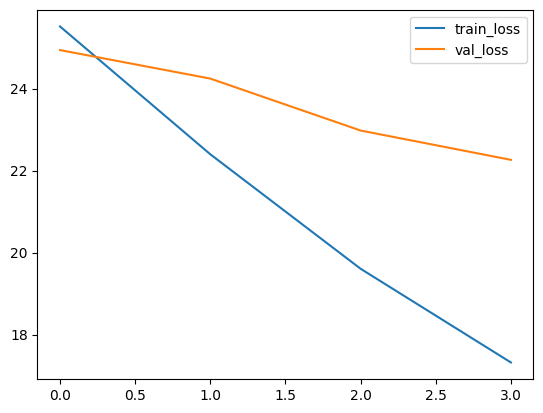

In [47]:
df[["train_loss", "val_loss"]].plot()

<Axes: >

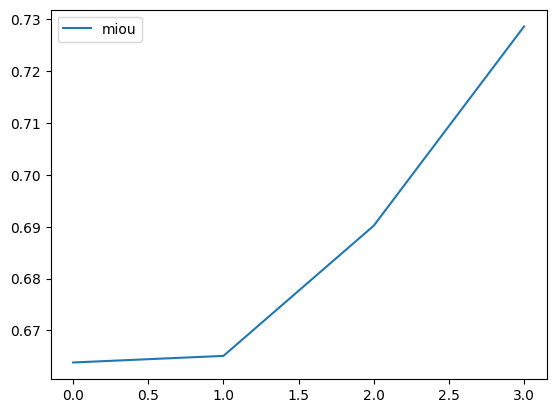

In [48]:
df[["miou"]].plot()

## 可视化

In [52]:
CITYSCAPES_COLORS = [
    (128,  64, 128),   # road
    (244,  35, 232),   # sidewalk
    ( 70,  70,  70),   # building
    (102, 102, 156),   # wall
    (190, 153, 153),   # fence
    (153, 153, 153),   # pole
    (250, 170,  30),   # traffic light
    (220, 220,   0),   # traffic sign
    (107, 142,  35),   # vegetation
    (152, 251, 152),   # terrain
    ( 70, 130, 180),   # sky
    (220,  20,  60),   # person
    (255,   0,   0),   # rider
    (  0,   0, 142),   # car
    (  0,   0,  70),   # truck
    (  0,  60, 100),   # bus
    (  0,  80, 100),   # train
    (  0,   0, 230),   # motorcycle
    (119,  11,  32),   # bicycle
]

In [50]:
def colorize_mask(mask):
    """
    mask:
        [H, W]
        class IDs: 0~18
        ignore: 255
    """
    h, w = mask.shape
    color_mask = np.zeros(
        (h, w, 3),
        dtype=np.uint8
    )
    for class_id, color in enumerate(CITYSCAPES_COLORS):
        color_mask[
            mask == class_id
        ] = color
    # Ignore region
    color_mask[
        mask == IGNORE_INDEX
    ] = (0, 0, 0)

    return color_mask


def denormalize_image(image):
    
    mean = torch.tensor(
        [0.485, 0.456, 0.406],
        dtype=image.dtype,
        device=image.device
    ).view(3, 1, 1)
    
    std = torch.tensor(
        [0.229, 0.224, 0.225],
        dtype=image.dtype,
        device=image.device
    ).view(3, 1, 1)

    image = image * std + mean
    image = image.clamp(0, 1)
    image = (
        image
        .permute(1, 2, 0)
        .detach()
        .cpu()
        .numpy()
    )

    return image


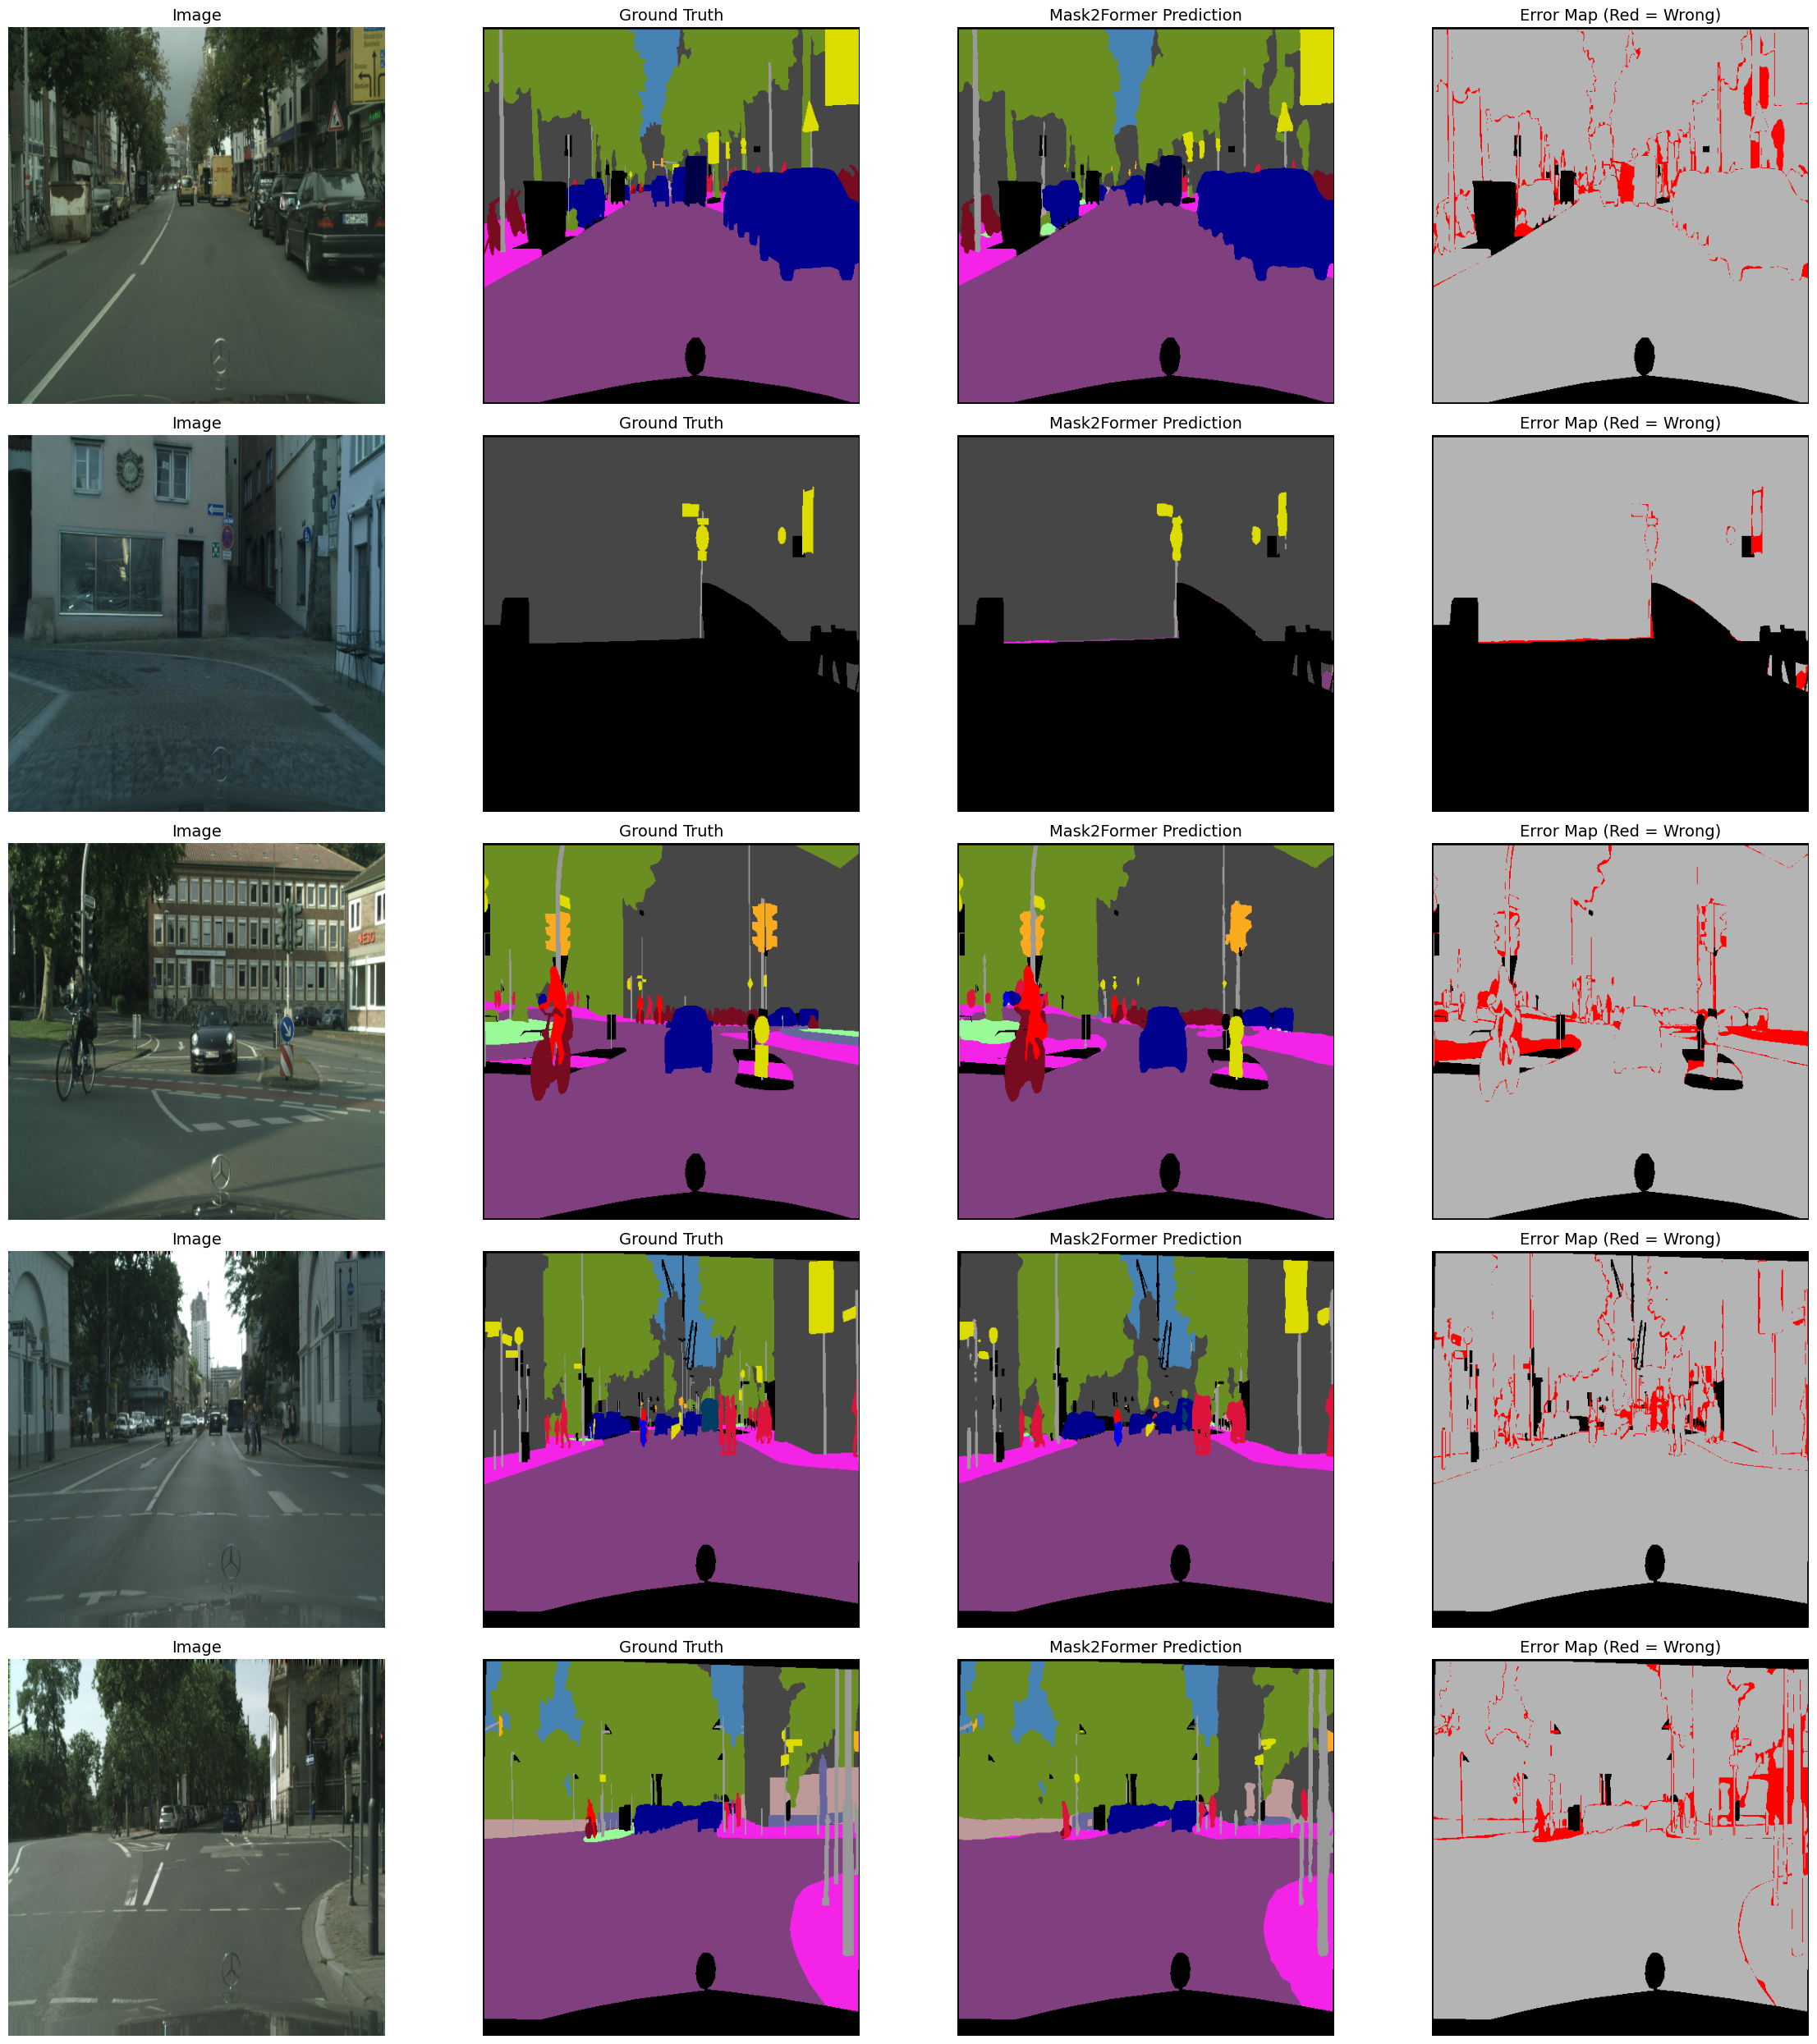

In [64]:
N = 5
random_indices = random.sample(
    range(len(val_dataset)),
    N
)

# Model
model.eval()

# Figure
fig, axes = plt.subplots(N, 4, figsize=(24, N * 5))
if N == 1:
    axes = axes.reshape(1, 4)

for row, idx in enumerate(random_indices):
    sample = val_dataset[idx]
    # Image
    pixel_values = sample["pixel_values"]
    pixel_mask = sample["pixel_mask"]

    # Original semantic GT
    gt_mask = sample["semantic_mask"]
    gt_np = (
        gt_mask
        .cpu()
        .numpy()
        .astype(np.uint8)
    )
    valid = (
        gt_np != IGNORE_INDEX
    )

    # Denormalize image
    img_np = denormalize_image(pixel_values)
    # GT visualization
    gt_color = colorize_mask(gt_np)

    # Mask2Former inference
    pixel_values_input = (
        pixel_values
        .unsqueeze(0)
        .to(DEVICE)
    )
    if pixel_mask is not None:
        pixel_mask_input = (
            pixel_mask
            .unsqueeze(0)
            .to(DEVICE)
        )
    else:
        pixel_mask_input = None


    with torch.no_grad():

        outputs = model(
            pixel_values=pixel_values_input,
            pixel_mask=pixel_mask_input,
        )

    # Mask2Former → semantic segmentation
    target_sizes = [
        (
            gt_np.shape[0],
            gt_np.shape[1]
        )
    ]
    predictions = (
        processor
        .post_process_semantic_segmentation(
            outputs,
            target_sizes=target_sizes,
        )
    )
    pred_mask = (
        predictions[0]
        .cpu()
        .numpy()
        .astype(np.uint8)
    )

    # Prediction visualization
    pred_mask_vis = pred_mask.copy()
    # Do not visualize prediction
    # in ignored GT regions
    pred_mask_vis[
        ~valid
    ] = IGNORE_INDEX
    pred_color = colorize_mask(pred_mask_vis)

    # Error Map
    diff = np.zeros(
        (
            gt_np.shape[0],
            gt_np.shape[1],
            3
        ),
        dtype=np.uint8
    )
    correct = (
        (pred_mask == gt_np)
        & valid
    )
    incorrect = (
        (pred_mask != gt_np)
        & valid
    )
    # Correct = gray
    diff[
        correct
    ] = (180, 180, 180)
    # Wrong = red
    diff[
        incorrect
    ] = (255, 0, 0)
    # Ignore = black
    diff[
        ~valid
    ] = (0, 0, 0)

    # Original Image
    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title("Image", fontsize=14)
    axes[row, 0].axis("off")

    # Ground Truth
    axes[row, 1].imshow(gt_color)
    axes[row, 1].set_title("Ground Truth", fontsize=14)
    axes[row, 1].axis("off")

    # Prediction
    axes[row, 2].imshow(pred_color)
    axes[row, 2].set_title("Mask2Former Prediction", fontsize=14)
    axes[row, 2].axis("off")

    # Error Map
    axes[row, 3].imshow(diff)
    axes[row, 3].set_title("Error Map (Red = Wrong)", fontsize=14)
    axes[row, 3].axis("off")


plt.tight_layout()
plt.show()

# 加载预训练模型推理百度街景

In [17]:
import os
import cv2
import math
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import transformers
from transformers import (
    AutoImageProcessor,
    Mask2FormerForUniversalSegmentation,
)

from huggingface_hub import snapshot_download

In [18]:
print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)

Transformers: 5.16.1
PyTorch: 2.10.0+cu126


## 下载mask2former-swin-large-cityscapes-semantic

- https://huggingface.co/facebook/mask2former-swin-large-cityscapes-semantic

In [ ]:
MODEL_ID = "facebook/mask2former-swin-large-cityscapes-semantic"
MODEL_DIR = "Model/mask2former-swin-large-cityscapes-semantic"

In [ ]:
snapshot_download(
    repo_id=MODEL_ID,
    local_dir=MODEL_DIR,
)

## 加载模型

In [20]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
device

device(type='cuda')

In [23]:
processor = AutoImageProcessor.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
)

model = Mask2FormerForUniversalSegmentation.from_pretrained(
    MODEL_DIR,
    local_files_only=True,
)
model.to(device)
model.eval()

Loading weights:   0%|          | 0/758 [00:00<?, ?it/s]

[transformers] Mask2FormerForUniversalSegmentation LOAD REPORT from: E:\JupyterLab\Model\CV\mask2former-swin-large-cityscapes-semantic
Key                                                                                                                      | Status     | 
-------------------------------------------------------------------------------------------------------------------------+------------+-
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED | 
model.pixel_level_module.encoder.swin.layernorm.bias                                                                     | MISSING    | 
model.pixel_level_module.encoder.swin.layernorm.weight                                                                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because miss

Mask2FormerForUniversalSegmentation(
  (model): Mask2FormerModel(
    (pixel_level_module): Mask2FormerPixelLevelModule(
      (encoder): SwinBackbone(
        (swin): SwinModel(
          (embeddings): SwinEmbeddings(
            (patch_embeddings): SwinPatchEmbeddings(
              (projection): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
            )
            (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (encoder): SwinEncoder(
            (layers): ModuleList(
              (0): SwinStage(
                (blocks): ModuleList(
                  (0): SwinLayer(
                    (attention): SwinAttention(
                      (q_proj): Linear(in_features=192, out_features=192, bias=True)
                      (k_proj): Linear(in_features=192, out_features=192, bias=True)
                      (v_proj): Linear(in_features=192, out_features=192, bias=True)
                      (o

## 推理

In [8]:
CLASS_NAMES = [
    "road",
    "sidewalk",
    "building",
    "wall",
    "fence",
    "pole",
    "traffic light",
    "traffic sign",
    "vegetation",
    "terrain",
    "sky",
    "person",
    "rider",
    "car",
    "truck",
    "bus",
    "train",
    "motorcycle",
    "bicycle",
]
code2name = {i: name for i, name in enumerate(CLASS_NAMES)} 

# Cityscapes 常用颜色
CITYSCAPES_COLORS = np.array([
    [128, 64, 128],
    [244, 35, 232],
    [70, 70, 70],
    [102, 102, 156],
    [190, 153, 153],
    [153, 153, 153],
    [250, 170, 30],
    [220, 220, 0],
    [107, 142, 35],
    [152, 251, 152],
    [70, 130, 180],
    [220, 20, 60],
    [255, 0, 0],
    [0, 0, 142],
    [0, 0, 70],
    [0, 60, 100],
    [0, 80, 100],
    [0, 0, 230],
    [119, 11, 32],
], dtype=np.uint8)

In [9]:
def mask_to_color(mask):

    color_mask = np.zeros(
        (
            mask.shape[0],
            mask.shape[1],
            3,
        ),
        dtype=np.uint8,
    )

    for class_id in range(len(CITYSCAPES_CLASSES)):

        color_mask[
            mask == class_id
        ] = CITYSCAPES_COLORS[class_id]

    return color_mask

def predict(image):

    inputs = processor(images=image, return_tensors="pt",)

    inputs = {
        key: value.to(device)
        if torch.is_tensor(value)
        else value
        for key, value in inputs.items()
    }

    with torch.inference_mode():
        outputs = model(**inputs)

    segmentation = (
        processor
        .post_process_semantic_segmentation(
            outputs,
            target_sizes=[image.size[::-1]],
        )[0]
    )

    return segmentation.cpu().numpy()


def panorama_to_perspective(image, heading=0, fov=90, output_size=1024):
    """
    4096×1024百度水平全景图 -> 透视视图
    全景 -> 平面
    """

    pano = np.asarray(image)
    pano_h, pano_w = pano.shape[:2]
    W = output_size
    H = output_size

    # focal length
    f = (
        W / 2
        / math.tan(
            math.radians(fov / 2)
        )
    )

    # 输出像素坐标
    xx, yy = np.meshgrid(np.arange(W), np.arange(H))

    # 图像中心
    cx = (W - 1) / 2
    cy = (H - 1) / 2
    x = (xx - cx).astype(np.float32)
    y = (yy - cy).astype(np.float32)

    # 相机坐标
    # x: right
    # y: up
    # z: forward
    # y 使用负号：图像向下 -> 世界坐标向下
    x_cam = x
    y_cam = -y
    z_cam = np.full_like(x_cam, f)

    # normalize
    norm = np.sqrt(
        x_cam ** 2
        + y_cam ** 2
        + z_cam ** 2
    )
    x_cam /= norm
    y_cam /= norm
    z_cam /= norm

    # heading rotation
    theta = math.radians(heading)
    x_world = (
        x_cam * math.cos(theta)
        + z_cam * math.sin(theta)
    )
    z_world = (
        -x_cam * math.sin(theta)
        + z_cam * math.cos(theta)
    )
    y_world = y_cam

    # longitude
    longitude = np.arctan2(x_world, z_world)
    # latitude
    latitude = np.arcsin(
        np.clip(
            y_world,
            -1,
            1
        )
    )

    # panorama coordinate
    map_x = (
        longitude / (2 * np.pi)
        + 0.5
    ) * pano_w
    map_y = (
        0.5
        - latitude / np.pi
    ) * pano_h

    # remap
    map_x = map_x.astype(np.float32)
    map_y = map_y.astype(np.float32)
    perspective = cv2.remap(
        pano,
        map_x,
        map_y,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_WRAP
    )

    return Image.fromarray(perspective)

### 单张测试

In [ ]:
IMAGE_DIR = "data/徐汇区/街景"
OUTPUT_DIR = "data/徐汇区/分割结果"

SAMPLE = "121.46590752620926_31.191828627455266_09000300121905180826001979Y_final.png"

In [11]:
HEADINGS = [0, 90, 180, 270]  # 四个方向
FOV = 90  # 水平视场角
OUTPUT_SIZE = 1024  # 输出尺寸

In [ ]:
image = Image.open(os.path.join(IMAGE_DIR, SAMPLE)).convert("RGB")
print("Input size:", image.size)

for heading in HEADINGS:

    print(f"Processing heading: {heading}")

    view = panorama_to_perspective(
        image=image,
        heading=heading,
        fov=FOV,
        output_size=OUTPUT_SIZE,
    )

    output_path = os.path.join(OUTPUT_DIR,f"view_{heading:03d}.png")

    view.save(output_path)

    print("Saved:", output_path)

In [ ]:
image_files = [
    "view_000.png",
    "view_090.png",
    "view_180.png",
    "view_270.png",
]
all_results = []
df = pd.DataFrame(
    0.0,  # 初始值全部为0
    index=image_files,  # 行索引为图片名
    columns=range(len(CLASS_NAMES))  # 列索引为0-18
)

for filename in image_files:

    # 读取
    image_path = os.path.join(OUTPUT_DIR,filename)
    image = Image.open(image_path).convert("RGB")  

    # 推理
    mask = predict(image)  

    # 类别统计
    unique, counts = np.unique(mask, return_counts=True)
    for class_id, count in zip(unique, counts):

        class_id = int(class_id)

        if 0 <= class_id < len(CLASS_NAMES):

            ratio = (count / mask.size) * 100
            df.loc[filename, class_id] = ratio

    # 删除推理完毕的照片
    if os.path.exists(image_path):
        try:
            os.remove(image_path)
        except Exception as e:
            print(f"删除失败 {filename}: {e}")
    else:
        print(f"文件不存在: {filename}")

# 生成四个方向的实例百分比            
df.columns = [code2name[i] for i in df.columns]
df = df.reset_index(names=['view'])
df["name"] = SAMPLE

In [14]:
df

,view,road,sidewalk,building,wall,fence,pole,traffic light,traffic sign,vegetation,...,sky,person,rider,car,truck,bus,train,motorcycle,bicycle,name
0,view_000.png,5.933094,1.216030,10.444736,5.704403,0.000000,0.747585,0.0,0.000000,49.923134,...,17.439461,0.000000,0.000000,0.014496,0.0,0.0,0.000000,0.0,0.000000,121.46590752620926_31.191828627455266_09000300...
1,view_090.png,28.951073,0.240421,10.085678,0.000000,0.000000,2.021313,0.0,0.043106,41.812992,...,7.632160,0.345898,0.162792,3.206635,0.0,0.0,0.000000,0.0,0.007915,121.46590752620926_31.191828627455266_09000300...
2,view_180.png,9.362888,10.379410,24.932766,8.193493,1.600552,1.695824,0.0,0.182343,30.655670,...,2.728462,0.000000,0.000000,9.125805,0.0,0.0,0.000000,0.0,0.000000,121.46590752620926_31.191828627455266_09000300...
3,view_270.png,26.679134,2.053547,0.874519,3.154850,1.094818,1.020241,0.0,0.036144,46.080208,...,6.390953,0.142765,0.000668,0.092888,0.0,0.0,1.319218,0.0,0.000000,121.46590752620926_31.191828627455266_09000300...


## 全量推理

In [ ]:
IMAGE_DIR = "data/徐汇区/街景"
OUTPUT_DIR = "data/徐汇区/分割结果"

HEADINGS = [0, 90, 180, 270]  # 四个方向
FOV = 90  # 水平视场角
OUTPUT_SIZE = 1024  # 输出尺寸

In [25]:
csv_path = os.path.join(OUTPUT_DIR, "all_results.csv")
processed_txt_path = os.path.join(OUTPUT_DIR, "processed_images.txt")
processed_error_txt_path = os.path.join(OUTPUT_DIR, "failed_images.txt")

In [24]:
# 查看已经推理过的图片
processed_names = set()  
if os.path.exists(processed_txt_path):
    with open(processed_txt_path, 'r', encoding='utf-8') as f:
        processed_names = set(line.strip() for line in f if line.strip())
    print(f"已处理 {len(processed_names)} 张图片，将继续处理剩余图片")

In [25]:
# 获取全部图片名称
image_files = [f for f in os.listdir(IMAGE_DIR) 
               if os.path.splitext(f)[1].lower()==".png"]

# 过滤已经推理过的图片
image_files_to_process = [f for f in image_files if f not in processed_names]
image_files_to_process[:5]

['121.38788428664716_31.167548239474783_0900030012210108131614445HH_final.png',
 '121.38817680597175_31.16668198255497_0900030012210108131812273HH_final.png',
 '121.38832068249464_31.16679723708209_0900030012200221075102996GF_final.png',
 '121.38846961737453_31.165815799053043_0900030012210108131821663HH_final.png',
 '121.38876242311044_31.16494961458956_0900030012210108131829995HH_final.png']

In [ ]:
csv_buffer = []
CSV_BUFFER_SIZE = 100  # 每100个样本写入一次CSV

In [30]:
for fig_name in tqdm(
    image_files_to_process, 
    desc="处理图片", 
    position=0, 
    leave=True, 
    bar_format="{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]"
):

    try:
        # 读取原始全景图
        image_path = os.path.join(IMAGE_DIR, fig_name)
        image = Image.open(image_path).convert("RGB")
        base_name = os.path.splitext(fig_name)[0]
        
        # 存储当前样本的所有视图结果
        rows_to_append = []
        
        # 循环生成四个方向的视图并推理
        for heading in HEADINGS:
            # 生成透视视图（直接在内存中，不保存到磁盘）
            view = panorama_to_perspective(
                image=image,
                heading=heading,
                fov=FOV,
                output_size=OUTPUT_SIZE,
            )
            
            # 推理（使用推理模式）
            with torch.no_grad():
                mask = predict(view)
            
            # 类别统计
            unique, counts = np.unique(mask, return_counts=True)
            
            # 创建当前view的统计数据
            view_filename = f"view_{heading:03d}.png"
            row_data = {'view': view_filename, 'name': fig_name}
            for class_name in CLASS_NAMES:  # 初始化所有类别为0
                row_data[class_name] = 0.0
            
            # 填充实际检测到的类别
            valid_indices = (unique >= 0) & (unique < len(CLASS_NAMES))  # 过滤有效类别
            valid_unique = unique[valid_indices].astype(int)
            valid_counts = counts[valid_indices]

            # 批量计算并赋值
            if len(valid_unique) > 0:
                ratios = (valid_counts / mask.size) * 100
                for class_id, ratio in zip(valid_unique, ratios):
                    row_data[code2name[class_id]] = ratio
            
            rows_to_append.append(row_data)
        
        # 将当前样本的结果添加到缓存
        csv_buffer.extend(rows_to_append)
        
        # 当缓存达到阈值时，批量写入CSV
        if len(csv_buffer) >= CSV_BUFFER_SIZE:
            df_append = pd.DataFrame(csv_buffer)
            df_append = df_append[['view', 'name'] + CLASS_NAMES]
            df_append.to_csv(csv_path, mode='a', index=False)
            csv_buffer.clear()  # 清空缓存
        
        # 记录已处理的文件
        with open(processed_txt_path, 'a', encoding='utf-8') as f:
            f.write(fig_name + '\n')
            
    except Exception as e:
        with open(processed_error_txt_path, 'a', encoding='utf-8') as f:
            f.write(f"{fig_name}\t{str(e)}\n")

处理图片: 100%|██████████| 7277/7277 [2:12:55<00:00]  


# 地理可视化

- 隧道内街景无法推理

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams['font.family'] = ['Arial', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
road = gpd.read_file("shp/road.shp")
xuhui = gpd.read_file("shp/xuhui.shp")
df = pd.read_csv("result/all_results.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29144 entries, 0 to 29143
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   view           29144 non-null  str  
 1   name           29144 non-null  str  
 2   road           29144 non-null  str  
 3   sidewalk       29144 non-null  str  
 4   building       29144 non-null  str  
 5   wall           29144 non-null  str  
 6   fence          29144 non-null  str  
 7   pole           29144 non-null  str  
 8   traffic light  29144 non-null  str  
 9   traffic sign   29144 non-null  str  
 10  vegetation     29144 non-null  str  
 11  terrain        29144 non-null  str  
 12  sky            29144 non-null  str  
 13  person         29144 non-null  str  
 14  rider          29144 non-null  str  
 15  car            29144 non-null  str  
 16  truck          29144 non-null  str  
 17  bus            29144 non-null  str  
 18  train          29144 non-null  str  
 19  motorcycle     

In [4]:
for c in df.columns:
    if c not in ["view", "name"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

In [5]:
df

,view,name,road,sidewalk,building,wall,fence,pole,traffic light,traffic sign,...,terrain,sky,person,rider,car,truck,bus,train,motorcycle,bicycle
0,view_000.png,121.39188919050136_31.17403330531309_090003001...,6.762123,16.463375,39.562893,0.485325,1.728725,0.059700,0.000000,0.000000,...,0.000000,0.277519,0.000000,2.788925,0.000000,0.000000,0.000000,0.0,0.000000,1.955509
1,view_090.png,121.39188919050136_31.17403330531309_090003001...,25.557041,11.211109,4.355431,5.175304,5.669594,0.773239,0.000000,0.285149,...,0.073051,2.609825,0.403404,1.406384,0.090599,0.000000,0.007629,0.0,0.000000,0.988579
2,view_180.png,121.39188919050136_31.17403330531309_090003001...,15.167236,3.618908,50.226498,0.494289,4.865265,0.000000,0.000000,0.000000,...,0.000000,0.000000,2.907467,0.203800,0.000000,0.000000,0.000000,0.0,0.000000,0.843525
3,view_270.png,121.39188919050136_31.17403330531309_090003001...,21.436882,7.999420,20.139790,0.000000,0.000000,0.227356,0.019550,0.066471,...,0.000000,4.289913,0.371265,5.044174,0.091553,0.000000,0.000000,0.0,4.562092,0.334740
4,view_000.png,121.39189672764506_31.176879080319928_09000300...,31.699276,0.000000,0.332069,0.000000,2.969074,0.690460,0.000000,0.128651,...,0.232410,30.056953,0.003242,0.000000,0.594234,0.285339,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29139,view_270.png,121.46487042912436_31.189642118324272_09000300...,24.680233,3.336334,1.644611,0.176048,0.329399,0.591087,0.000000,0.045967,...,10.171986,8.453083,0.043106,0.000000,0.090504,0.000000,0.000000,0.0,0.000000,0.000000
29140,view_000.png,121.46488851901783_31.19912093674233_090003001...,26.466179,2.754116,36.026764,0.000000,9.496021,2.392578,0.000000,0.393391,...,6.549072,6.526852,0.268936,0.000000,2.369690,0.097847,0.151062,0.0,0.000000,0.001526
29141,view_090.png,121.46488851901783_31.19912093674233_090003001...,32.777405,0.182056,25.514221,0.716114,5.589294,1.537514,0.085831,0.289345,...,1.476288,17.141914,0.373459,0.000000,5.561161,0.016880,0.076771,0.0,0.026894,0.000000
29142,view_180.png,121.46488851901783_31.19912093674233_090003001...,13.475990,6.714725,19.141388,0.456333,19.540787,1.015759,0.000000,0.030613,...,0.000191,0.000000,0.062466,0.214863,7.352257,0.000000,0.000000,0.0,0.762939,0.013161


In [6]:
road

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,fclass_cn,type,geometry
0,295084480,5113,primary,龙吴路,NaN,F,0,0,F,F,主要道路,城市主干路,"LINESTRING (121.4499 31.1032, 121.44993 31.103..."
1,295084483,5113,primary,龙吴路,NaN,F,0,0,F,F,主要道路,城市主干路,"LINESTRING (121.45177 31.09777, 121.45171 31.0..."
2,1031105633,5113,primary,龙吴路,NaN,F,0,0,F,F,主要道路,城市主干路,"LINESTRING (121.44947 31.10846, 121.44945 31.1..."
3,47005039,5113,primary,龙吴路,NaN,F,0,0,F,F,主要道路,城市主干路,"LINESTRING (121.45003 31.10325, 121.44982 31.1..."
4,1031105540,5122,residential,NaN,NaN,B,0,0,F,F,居住区道路,城市支路,"LINESTRING (121.44962 31.10844, 121.44947 31.1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4159,515126304,5113,primary,NaN,NaN,F,0,0,F,F,主要道路,城市主干路,"LINESTRING (121.45534 31.22575, 121.45535 31.2..."
4160,515124966,5122,residential,茂名南路,NaN,F,0,0,F,F,居住区道路,城市支路,"LINESTRING (121.45625 31.22595, 121.45625 31.2..."
4161,515126385,5113,primary,延安中路,NaN,F,0,0,F,F,主要道路,城市主干路,"LINESTRING (121.45625 31.22595, 121.45625 31.2..."
4162,513082641,5112,trunk,延安高架路,NaN,F,0,1,T,F,干道,高架及快速路,"LINESTRING (121.45402 31.22572, 121.45605 31.2..."


### 计算指标

|指标缩写|指标全称|计算公式|Cityscapes类别说明|
|---|---|---|---|
|GVI|Green view index 绿视率|植被像素 / 图像总像素|树木tree、草地grass像素之和；树木、草地代表人眼可见绿化|
|Interface enclosure|街道界面围合度|垂直遮挡要素像素 / 图像总像素|建筑building、围墙wall、栅栏fence、高大乔木tree|
|SVF|Sky view factor 天空可视因子|天空sky像素 / 图像总像素|天空占比，数值越大街道越开阔通透|
|Vehicle pixel proportion|机动车像素占比|机动车像素 / 图像总像素|car、truck、bus、motorcycle、bicycle全部机动车/两轮车辆像素；视觉层面机动车干扰程度|
|Sidewalk proportion|人行道占比|sidewalk人行道像素 / 图像总像素|步行空间视觉占比，反映步行空间视觉宽度|
|Motorway proportion|机动车道占比|road机动车道路像素 / 图像总像素|车行铺装路面占比，车行空间视觉权重|

In [7]:
# 计算单张街景图像级6个指标
df["Green view index"] = df["vegetation"]
df["Interface enclosure"] = df["building"] + df["wall"] + df["fence"] + df["vegetation"]
df["Sky view factor"] = df["sky"]
df["Vehicle pixel proportion"] = df["car"] + df["truck"] + df["bus"] + df["motorcycle"] + df["bicycle"]
df["Sidewalk proportion"] = df["sidewalk"]
df["Motorway proportion"] = df["road"]

In [8]:
# 计算采样点上均值
metric_cols = [
    "Green view index",
    "Interface enclosure",
    "Sky view factor",
    "Vehicle pixel proportion",
    "Sidewalk proportion",
    "Motorway proportion"
]
df0 = df.groupby("name")[metric_cols].mean().dropna().reset_index()
df0

,name,Green view index,Interface enclosure,Sky view factor,Vehicle pixel proportion,Sidewalk proportion,Motorway proportion
0,121.38788428664716_31.167548239474783_09000300...,36.746120,46.294165,5.264282,12.874484,10.621929,22.446537
1,121.38817680597175_31.16668198255497_090003001...,21.141696,34.480453,19.408035,2.687550,1.427722,39.565039
2,121.38832068249464_31.16679723708209_090003001...,27.067637,36.178780,16.965818,2.283049,2.397037,38.375616
3,121.38846961737453_31.165815799053043_09000300...,52.749181,60.697246,3.309989,3.460479,4.742765,20.404387
4,121.38876242311044_31.16494961458956_090003001...,47.018790,58.509040,1.919198,3.359628,5.086255,21.776319
...,...,...,...,...,...,...,...
7236,121.46475017554933_31.189704892949266_09000300...,42.160702,50.886774,12.338781,0.311351,4.751301,21.616602
7237,121.4648100791764_31.18936989873105_0900030012...,52.330685,58.847380,5.159831,0.353193,5.373001,21.210361
7238,121.4648317702216_31.198604695442544_090003001...,22.514176,51.433063,6.309080,3.272104,3.499675,34.256554
7239,121.46487042912436_31.189642118324272_09000300...,44.870496,54.652095,12.891197,0.101113,5.732703,19.847703


In [9]:
# 提取经纬度
df0[["lon","lat"]] = df0["name"].str.split("_", expand=True)[[0,1]]
df0["lon"] = df0["lon"].astype(float)
df0["lat"] = df0["lat"].astype(float)

In [10]:
df0

,name,Green view index,Interface enclosure,Sky view factor,Vehicle pixel proportion,Sidewalk proportion,Motorway proportion,lon,lat
0,121.38788428664716_31.167548239474783_09000300...,36.746120,46.294165,5.264282,12.874484,10.621929,22.446537,121.387884,31.167548
1,121.38817680597175_31.16668198255497_090003001...,21.141696,34.480453,19.408035,2.687550,1.427722,39.565039,121.388177,31.166682
2,121.38832068249464_31.16679723708209_090003001...,27.067637,36.178780,16.965818,2.283049,2.397037,38.375616,121.388321,31.166797
3,121.38846961737453_31.165815799053043_09000300...,52.749181,60.697246,3.309989,3.460479,4.742765,20.404387,121.388470,31.165816
4,121.38876242311044_31.16494961458956_090003001...,47.018790,58.509040,1.919198,3.359628,5.086255,21.776319,121.388762,31.164950
...,...,...,...,...,...,...,...,...,...
7236,121.46475017554933_31.189704892949266_09000300...,42.160702,50.886774,12.338781,0.311351,4.751301,21.616602,121.464750,31.189705
7237,121.4648100791764_31.18936989873105_0900030012...,52.330685,58.847380,5.159831,0.353193,5.373001,21.210361,121.464810,31.189370
7238,121.4648317702216_31.198604695442544_090003001...,22.514176,51.433063,6.309080,3.272104,3.499675,34.256554,121.464832,31.198605
7239,121.46487042912436_31.189642118324272_09000300...,44.870496,54.652095,12.891197,0.101113,5.732703,19.847703,121.464870,31.189642


### 可视化

In [11]:
# 转点
gdf = gpd.GeoDataFrame(df0.drop(columns=["name","lon","lat"]), geometry=gpd.points_from_xy(df0.lon, df0.lat), crs=4326)

In [12]:
gdf

,Green view index,Interface enclosure,Sky view factor,Vehicle pixel proportion,Sidewalk proportion,Motorway proportion,geometry
0,36.746120,46.294165,5.264282,12.874484,10.621929,22.446537,POINT (121.38788 31.16755)
1,21.141696,34.480453,19.408035,2.687550,1.427722,39.565039,POINT (121.38818 31.16668)
2,27.067637,36.178780,16.965818,2.283049,2.397037,38.375616,POINT (121.38832 31.1668)
3,52.749181,60.697246,3.309989,3.460479,4.742765,20.404387,POINT (121.38847 31.16582)
4,47.018790,58.509040,1.919198,3.359628,5.086255,21.776319,POINT (121.38876 31.16495)
...,...,...,...,...,...,...,...
7236,42.160702,50.886774,12.338781,0.311351,4.751301,21.616602,POINT (121.46475 31.1897)
7237,52.330685,58.847380,5.159831,0.353193,5.373001,21.210361,POINT (121.46481 31.18937)
7238,22.514176,51.433063,6.309080,3.272104,3.499675,34.256554,POINT (121.46483 31.1986)
7239,44.870496,54.652095,12.891197,0.101113,5.732703,19.847703,POINT (121.46487 31.18964)


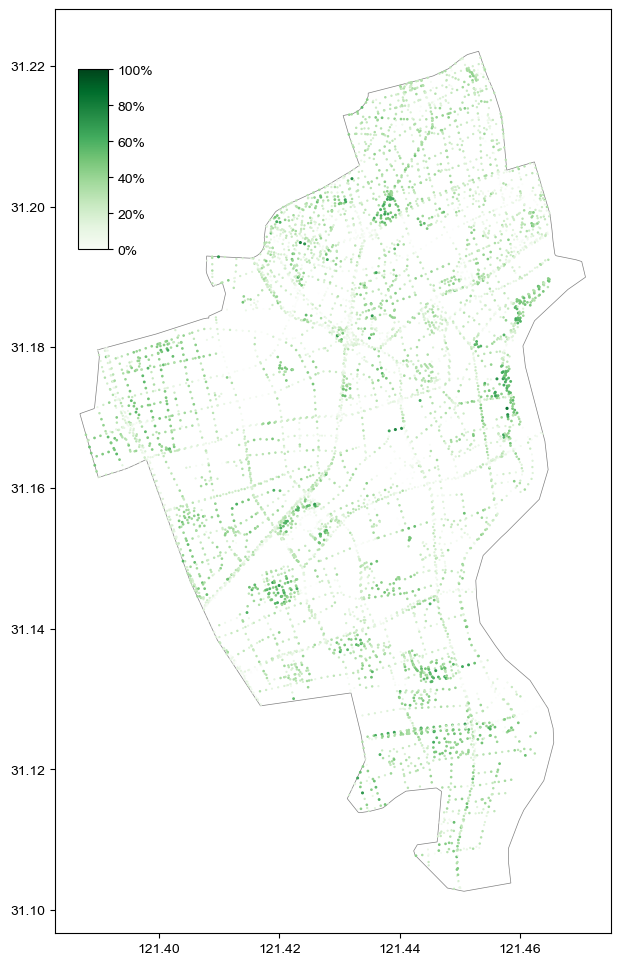

In [13]:
fig, ax = plt.subplots(figsize=(12, 12))
col = "Green view index"
gdf.plot(
    column=col,
    markersize=gdf[col] / 50,
    cmap="Greens",
    norm=mcolors.Normalize(vmin=0, vmax=100),
    zorder=3,
    ax=ax
)
xuhui.boundary.plot(
    lw=0.5,
    color="grey",
    zorder=2,
    ax=ax
)

sm = plt.cm.ScalarMappable(
    cmap="Greens",
    norm=mcolors.Normalize(vmin=0, vmax=100)
)
sm.set_array([])
# [left, bottom, width, height] 相对于figure的比例（0-1之间）
cbar_ax = fig.add_axes([0.3, 0.68, 0.025, 0.15])  # [左, 下, 宽, 高]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
ticks = [0, 20, 40, 60, 80, 100]
cbar.set_ticks(ticks)
cbar.set_ticklabels([f'{t}%' for t in ticks])

plt.show()

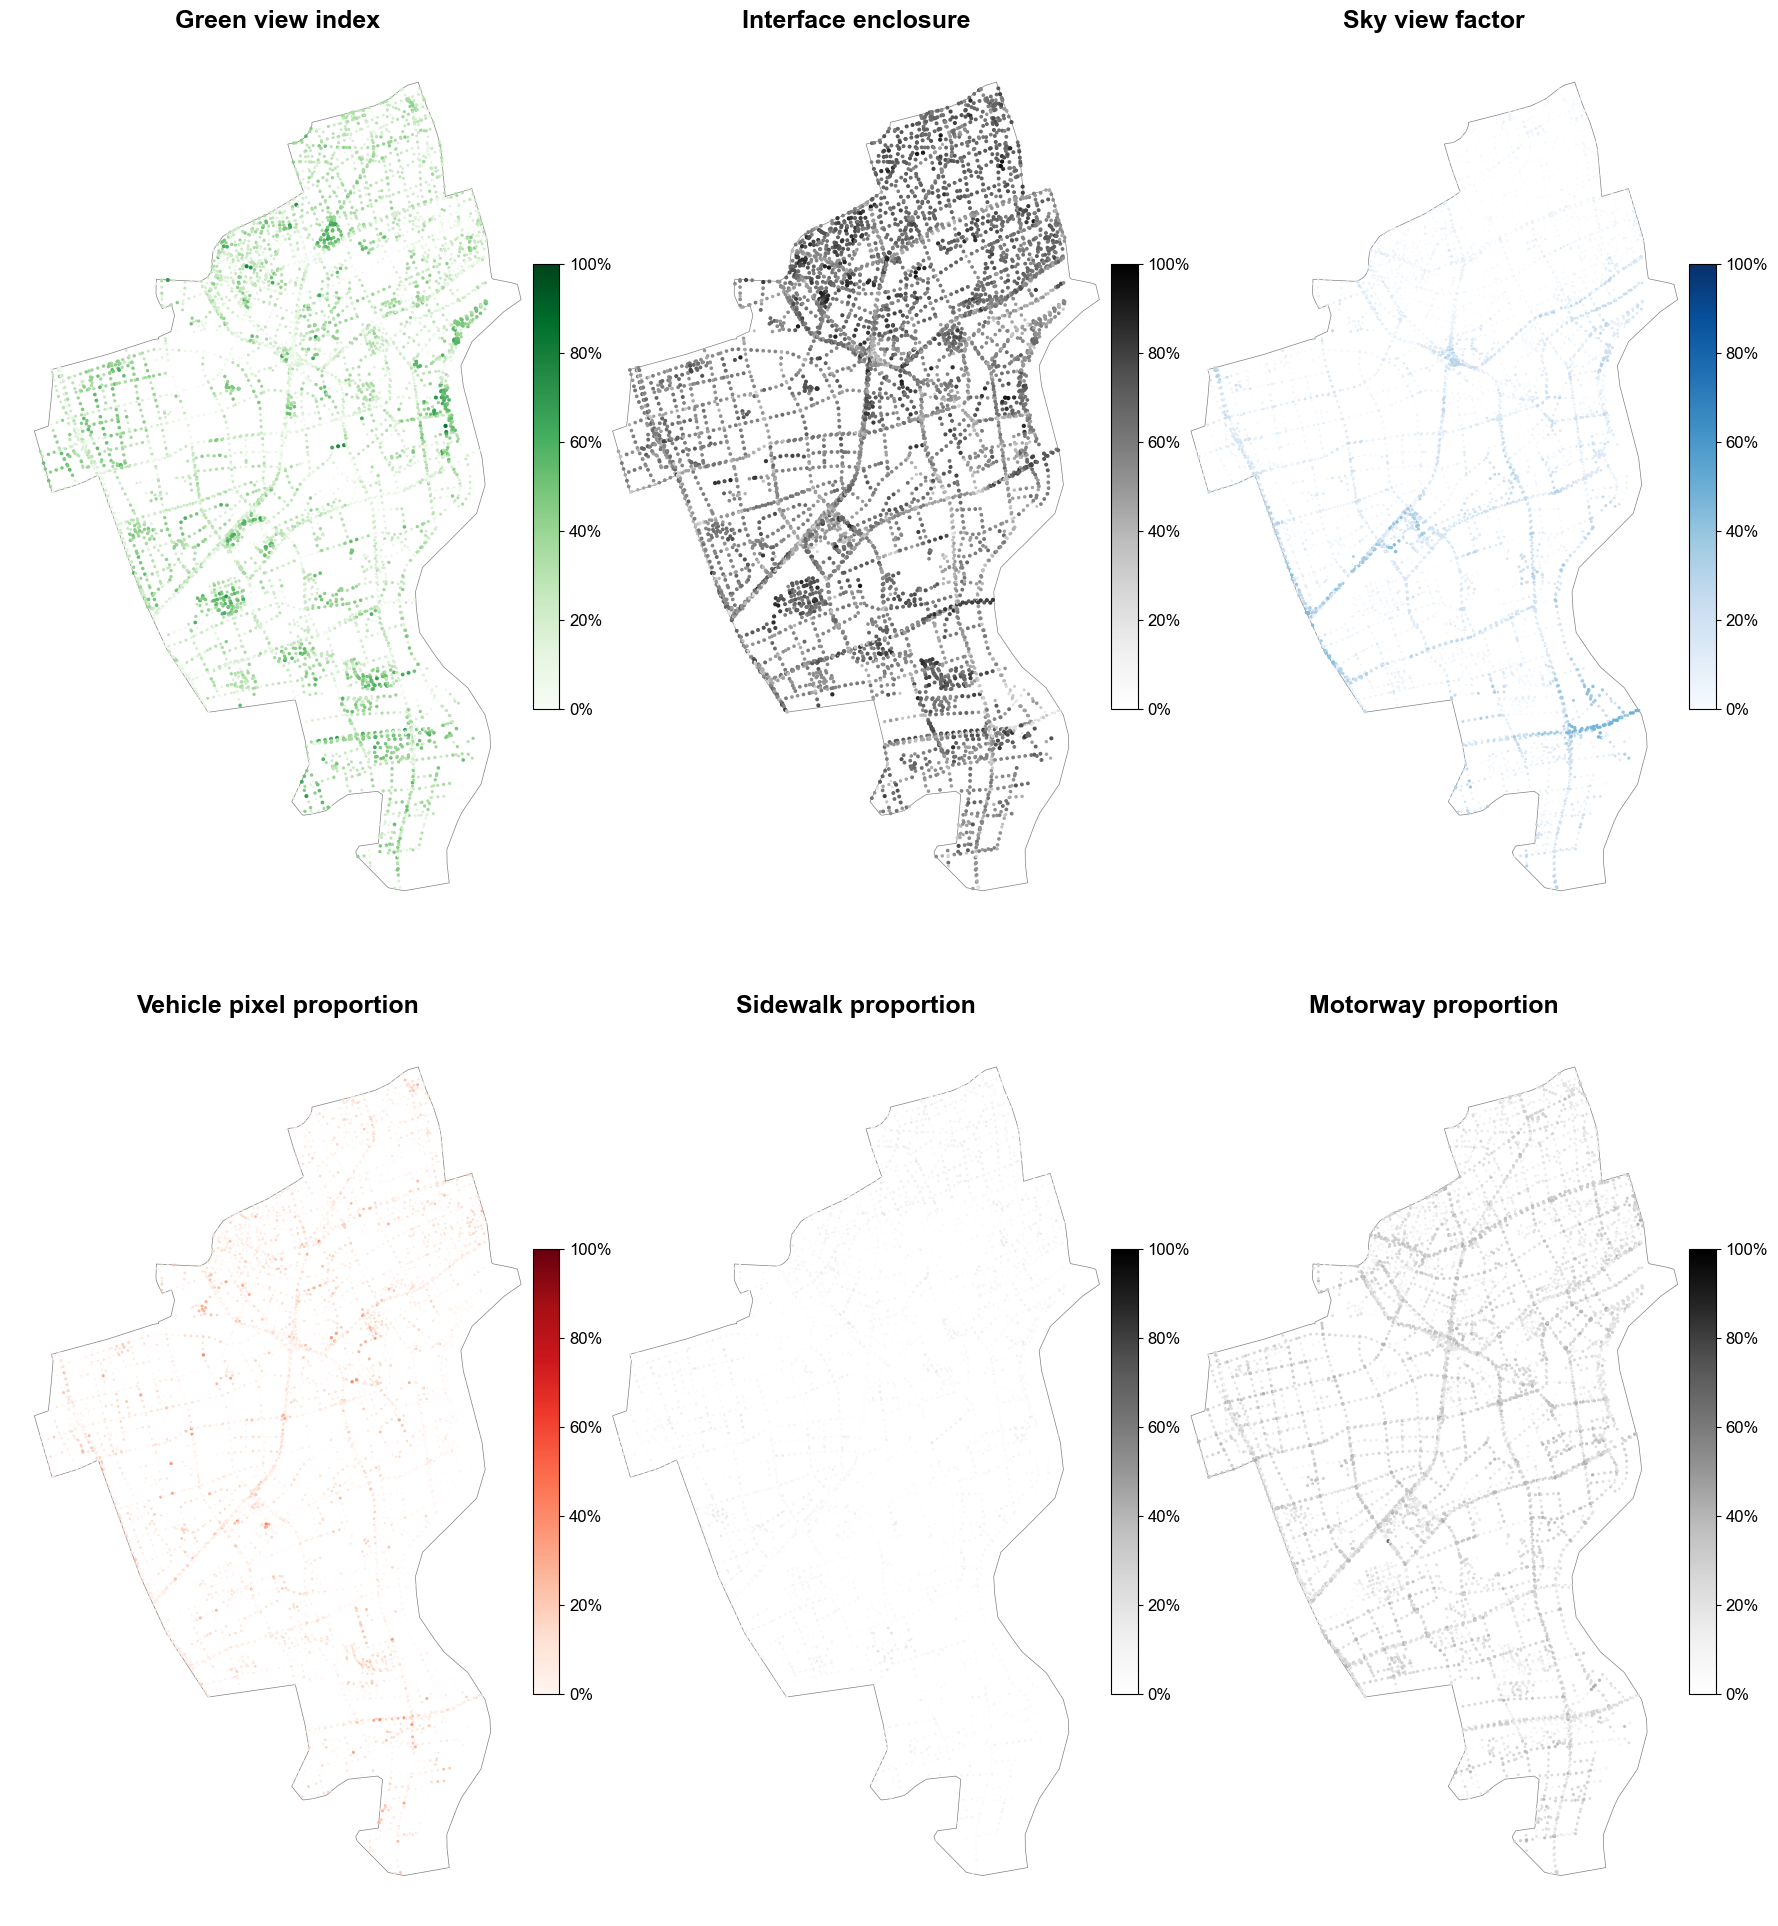

In [14]:
columns = gdf.drop(columns="geometry").columns
cmaps = ["Greens", "Greys", "Blues", "Reds", "Greys", "Greys"]

fig = plt.figure(figsize=(18, 20))

gs = fig.add_gridspec(
    nrows=2,
    ncols=3,
    left=0.03,
    right=0.97,
    bottom=0.03,
    top=0.97,
    wspace=0.08,
    hspace=0.10
)

axes = gs.subplots()

for i, col in enumerate(columns):

    ax = axes.flat[i]

    cmap = plt.get_cmap(cmaps[i % len(cmaps)])
    norm = mcolors.Normalize(vmin=0, vmax=100)

    gdf.plot(
        column=col,
        markersize=gdf[col] / 20,
        cmap=cmap,
        norm=norm,
        zorder=3,
        ax=ax
    )
    xuhui.boundary.plot(
        lw=0.5,
        color="grey",
        zorder=2,
        ax=ax
    )
    ax.set_title(
        col,
        fontsize=18,
        fontweight="bold",
        pad=10
    )
    ax.axis("off")


    # CBar固定在每个 Axes 右侧
    cax = inset_axes(
        ax,
        width="5%",
        height="50%",
        loc="center right",
        borderpad=-1
    )

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        cax=cax,
        orientation="vertical",
        ticks=[0, 20, 40, 60, 80, 100]
    )
    cbar.ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
    cbar.ax.tick_params(labelsize=12)

plt.savefig("fig1.png", dpi=500, bbox_inches="tight")
plt.show()

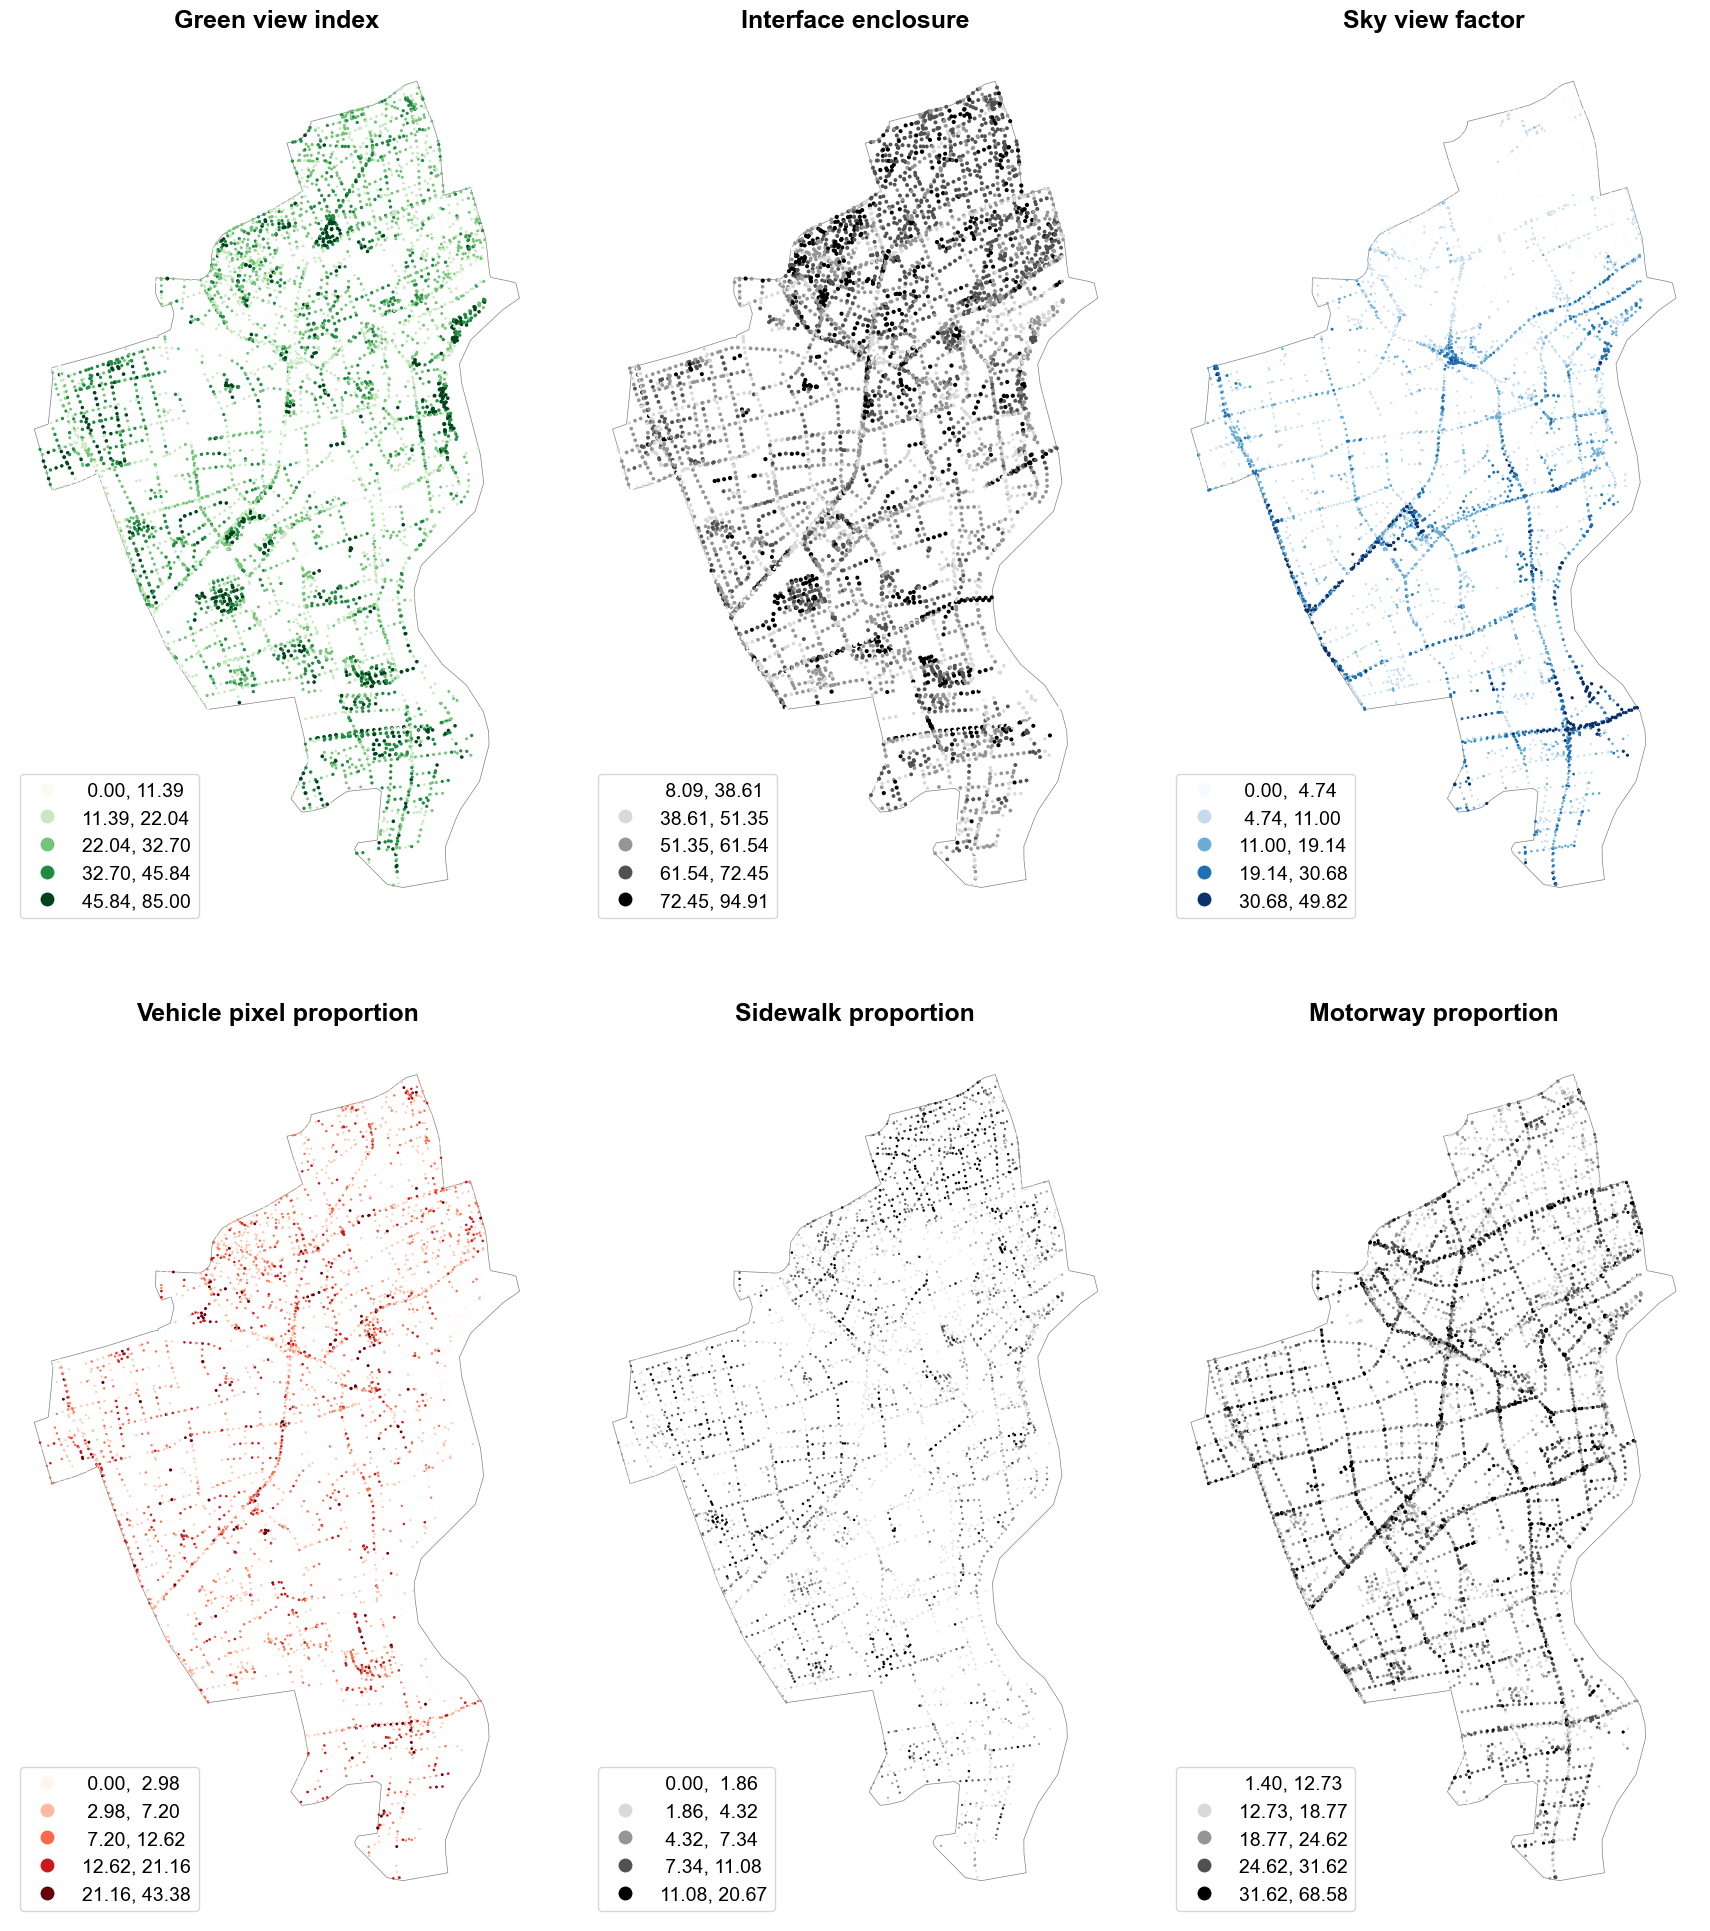

In [15]:
columns = gdf.drop(columns="geometry").columns
cmaps = ["Greens", "Greys", "Blues", "Reds", "Greys", "Greys"]

fig = plt.figure(figsize=(18, 20))

gs = fig.add_gridspec(
    nrows=2,
    ncols=3,
    left=0.03,
    right=0.97,
    bottom=0.03,
    top=0.97,
    wspace=0.08,  # 左右间距
    hspace=0.12  # 上下间距
)

axes = gs.subplots()

for i, col in enumerate(columns):

    ax = axes.flat[i]

    cmap = plt.get_cmap(cmaps[i % len(cmaps)])

    gdf.plot(
        column=col,
        markersize=gdf[col] / 20,
        scheme="NaturalBreaks",
        k=5,
        legend=True,
        legend_kwds={
            "loc": "lower left",
            "fontsize": 14,
            "title": None
        },
        cmap=cmap,
        zorder=3,
        ax=ax
    )
    xuhui.boundary.plot(
        lw=0.5,
        color="grey",
        zorder=2,
        ax=ax
    )
    ax.set_title(
        col,
        fontsize=18,
        fontweight="bold",
        pad=10
    )
    ax.axis("off")

plt.savefig("fig2.png", dpi=500, bbox_inches="tight")
plt.show()